Installing OpenAI CLIP and dependencies... (This may take a minute)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
Loading CLIP model on cpu...


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 71.4MiB/s]


Successfully processed: 480px-Cat03.jpg
Successfully processed: 480px-Cat_March_2010-1.jpg
Successfully processed: 480px-Red_Kitten_01.jpg
Skipping failed image https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/Trapez_Ridge_2.jpg/480px-Trapez_Ridge_2.jpg: 404 Client Error: Not Found for url: https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/Trapez_Ridge_2.jpg/480px-Trapez_Ridge_2.jpg
Successfully processed: 480px-Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg
Successfully processed: 480px-Crab_Nebula.jpg
Successfully processed: 480px-NGC_4414_%28NASA-med%29.jpg
Embeddings Shape: (6, 512)
Clustering into 3 clusters...


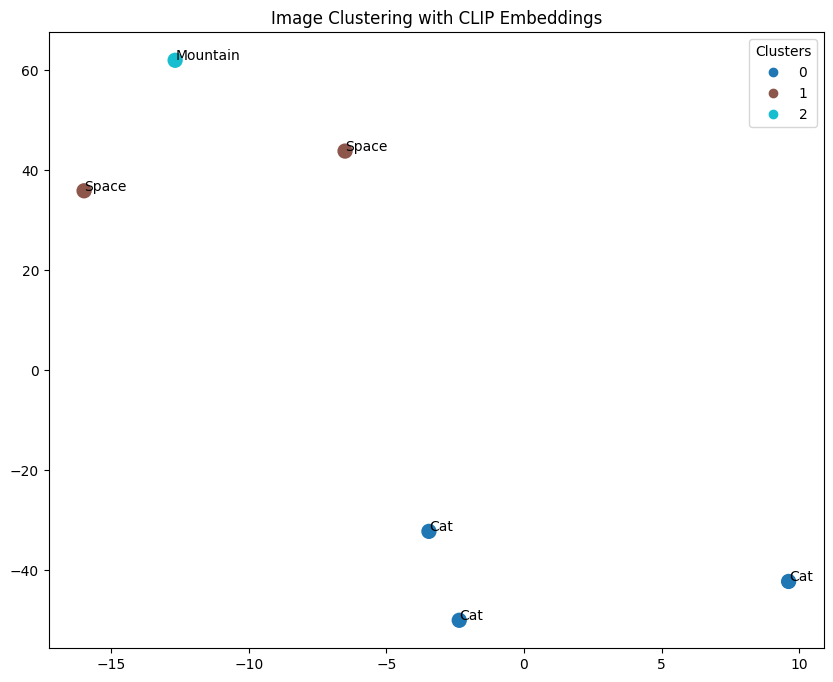

Cluster Labels: [0 0 0 2 1 1]


In [2]:


import os
import sys

# --- 1. Automatic Installation ---
try:
    import clip
    import torch
    print("Libraries already installed.")
except ImportError:
    print("Installing OpenAI CLIP and dependencies... (This may take a minute)")
    # Install CLIP directly from GitHub
    !pip install git+https://github.com/openai/CLIP.git --quiet
    !pip install torch torchvision --quiet

import torch
import clip
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# --- 2. Setup Model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP model on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

# --- 3. Data Preparation (Download Samples) ---
# Wikimedia Commons images
image_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/480px-Cat03.jpg", # Cat
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_March_2010-1.jpg/480px-Cat_March_2010-1.jpg", # Cat
    "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Red_Kitten_01.jpg/480px-Red_Kitten_01.jpg", # Cat
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/Trapez_Ridge_2.jpg/480px-Trapez_Ridge_2.jpg", # Mountain
    "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg/480px-Everest_North_Face_toward_Base_Camp_Tibet_Luca_Galuzzi_2006.jpg", # Mountain
    "https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/Crab_Nebula.jpg/480px-Crab_Nebula.jpg", # Space
    "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/NGC_4414_%28NASA-med%29.jpg/480px-NGC_4414_%28NASA-med%29.jpg" # Space
]

print("Downloading and processing images...")
embeddings = []
valid_images = []
valid_labels_text = []

# Headers to mimic a real browser to avoid 403 Forbidden errors
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

categories_gt = ["Cat", "Cat", "Cat", "Mountain", "Mountain", "Space", "Space"]

for i, url in enumerate(image_urls):
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Check for HTTP errors

        image = Image.open(BytesIO(response.content)).convert("RGB")

        # Preprocess and generate embedding
        image_input = preprocess(image).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image_input)

        # Normalize
        image_features /= image_features.norm(dim=-1, keepdim=True)
        embeddings.append(image_features.cpu().numpy().flatten())

        valid_images.append(image)
        valid_labels_text.append(categories_gt[i])
        print(f"Successfully processed: {url.split('/')[-1]}")

    except Exception as e:
        print(f"Skipping failed image {url}: {e}")

if not embeddings:
    print("No images were loaded. Check your internet connection.")
else:
    embeddings = np.array(embeddings)
    print(f"Embeddings Shape: {embeddings.shape}")

    # --- 4. Clustering ---
    n_clusters = 3
    # Handle edge case if fewer images downloaded than clusters
    if len(embeddings) < n_clusters:
        n_clusters = len(embeddings)

    print(f"Clustering into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    # --- 5. Visualization ---
    # We use TSNE to project to 2D
    # Perplexity must be less than number of samples
    perp = min(2, len(embeddings)-1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='random')
    projections = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(projections[:, 0], projections[:, 1], c=labels, cmap='tab10', s=100)

    # Annotate with text
    for i, txt in enumerate(valid_labels_text):
        plt.annotate(txt, (projections[i, 0]+0.01, projections[i, 1]+0.01))

    plt.title("Image Clustering with CLIP Embeddings")
    plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.show()

    print("Cluster Labels:", labels)